<div style="text-align:center; padding:20px 0">
<img src="https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/media/logo_dataprojectlab.png" width="220"/>
</div>

# AfriCare Support Analytics
## Notebook 5 - Machine Learning : Detection de tickets a risque
### VERSION CORRIGEE

---

> **Comment lire ce notebook :**
> Chaque etape ML est precedee d'une cellule qui explique le POURQUOI avant le COMMENT.
> Les blocs `POINT PEDAGOGIQUE` expliquent les regles generalisables a tout projet ML.
> Les blocs `POINT METIER` font le lien entre la technique et la decision de M. Kouame.

---

| Info | Detail |
|---|---|
| **Prerequis** | `support_clean_analytics.csv` genere en Notebook 2 |
| **Objectif** | Detecter les tickets a risque des leur creation |
| **Sortie** | `tickets_risque_scores.csv` pour Power BI |
| **Duree** | 5h a 6h |
| **Competences** | Classification binaire - Coupure temporelle - Seuil optimal - TimeSeriesSplit |

---

### Plan

```
1.  Imports
2.  Chargement
3.  Contexte ML
4.  Analyse de la cible
5.  Features et encodage
6.  Coupure temporelle
7.  3 modeles + matrices de confusion
8.  Feature importance + ROC
9.  Optimisation du seuil
10. Fichier alertes Power BI
11. Validation croisee temporelle
12. Synthese
```

---

# 1. Imports & configuration

> **POINT PEDAGOGIQUE - Pourquoi `compute_sample_weight` ?**
>
> En classification desequilibree, les modeles ignorent la classe minoritaire
> et predisent tout 'normal' - 100% accuracy mais Recall=0% sur les risques.
>
> `compute_sample_weight('balanced', y_train)` calcule un poids par observation
> inversement proportionnel a sa frequence de classe. La classe minoritaire recoit
> un poids plus eleve, forcant le modele a lui accorder plus d'attention.
>
> Alternative : `class_weight='balanced'` dans RandomForest et LogisticRegression.
> Pour GradientBoosting (pas de `class_weight`), on passe les poids dans `.fit(sample_weight=sw)`.
>
> **3 groupes de metriques :**
> - `roc_auc_score` : discrimination globale, independante du seuil
> - `classification_report` : precision + recall + F1 par classe
> - `precision_recall_curve` : pour choisir le seuil optimal (section 9)

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, precision_recall_curve, f1_score,
                              precision_score, recall_score, accuracy_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

plt.rcParams.update({"figure.facecolor":"white",
                     "axes.facecolor":"#F9F9F8",
                     "axes.grid":True,
                     "grid.alpha":0.35,
                     "font.size":11})

COLORS = {"primary":"#534AB7",
          "secondary":"#1D9E75",
          "warning":"#EF9F27",
          "danger":"#E24B4A",
          "neutral":"#888780"}

import os
import sys

# Détecter si on est dans Colab ou en local
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_PATH = "/content/drive/MyDrive/DataProjectLab/projects/customer_support_analytics/"
else:
    SAVE_PATH = "./outputs/"

# Chemin pour enregistrer les fichiers exportés
os.makedirs(SAVE_PATH, exist_ok=True)
print(f" Environnement Colab : {'Colab' if IN_COLAB else 'Local'}")
print(f" Dossier de travail : {SAVE_PATH}")

print("Librairies ML chargees")
print("Note : pip install shap pour les explications SHAP")

 Environnement Colab : Local
 Dossier de travail : ./outputs/
Librairies ML chargees
Note : pip install shap pour les explications SHAP


---

# 2. Chargement des donnees

> **POINT PEDAGOGIQUE - Chaque notebook recharge ses propres donnees.**
>
> Chaque notebook doit etre autonome - executable independamment.
> Si `support_clean_analytics.csv` est absent, on obtient un `FileNotFoundError`
> - signal clair que le prerequis (Notebook 2) manque.
>
> **`parse_dates=['created_at']`** est essentiel pour la coupure temporelle.
> Sans lui, le tri par date serait alphabetique (incorrect).

In [2]:
BASE_URL = "https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/projets/customer_support_analytics/data/"
clean_path = f"{SAVE_PATH}support_clean_analytics.csv"

# Vérifier si le fichier nettoyé existe (produit par le NB2)
# Sinon, fallback vers les données brutes GitHub
if os.path.exists(clean_path):
    file_source = clean_path
    print(f"✅ Fichier nettoyé trouvé : {clean_path}")
else:
    file_source = BASE_URL + "support_clean_analytics.csv"
    print(f"⚠️  Fichier nettoyé non trouvé — chargement depuis GitHub")
    print(f"   → Exécute le Notebook 2 pour produire le fichier nettoyé")

df = pd.read_csv(f"{file_source}", parse_dates=["created_at"])


print(f"Shape : {df.shape}")
print(f"Periode : {df['created_at'].min().date()} -> {df['created_at'].max().date()}")
display(df.head(3))

✅ Fichier nettoyé trouvé : ./outputs/support_clean_analytics.csv
Shape : (15287, 37)
Periode : 2022-01-01 -> 2024-06-30


,ticket_id,created_at,category_id,agent_id,pays,canal,priorite,statut,sla_heures,first_response_heures,...,sla_strict,heure_creation,jour_semaine,mois,est_weekend,heure_hors_bureau,ticket_at_risk,is_high_priority,is_long_wait,is_reopened
0,TKT000001,2022-01-01 08:06:00,CAT006,AGT001,Ghana,Email,3,Backlog,360,29.1,...,False,8,5,1,1,0,1,0,1,0
1,TKT000002,2022-01-01 13:45:00,CAT001,AGT004,CI,Téléphone,4,Résolu,240,56.2,...,True,13,5,1,1,0,1,0,1,0
2,TKT000003,2022-01-01 08:48:00,CAT008,AGT003,Maroc,Chat,2,Résolu,120,5.0,...,True,8,5,1,1,0,0,1,1,0


---

# 3. Contexte ML et definition du probleme

> **POINT METIER - Traduire le besoin de M. Kouame en probleme ML.**
>
> M. Kouame veut un outil qui predit si un ticket est a risque des sa creation. Il ne veut pas *constater* les problèmes après coup.
> Un **classificateur binaire** qui prend un ticket à l'instant T,
et retourne une probabilité de risque entre 0 et 1.
>
>Les superviseurs reçoivent une alerte en temps réel.
>Ils peuvent intervenir avant que le SLA soit breaché, avant que le ticket parte en backlog, avant que le client escalade.
>
> En langage ML :
> - **Probleme** : Classification binaire supervisee
> - **Variable cible y** : `ticket_at_risk` (1=risque, 0=normal)
> - **Moment de prediction** : a la creation du ticket
> - **Contrainte** : Recall > 0.75 sur la classe 'a risque'
>
> **Pourquoi Recall et pas Precision ?**
>
> - **Faux negatif** (Recall faible) : le modele rate un vrai ticket a risque.
>   Consequence : breach sans intervention. Cout eleve.
> - **Faux positif** (Precision faible) : alerte pour un ticket normal.
>   Consequence : 2 minutes perdues. Cout faible.
>
> Mieux vaut alerter trop que manquer un ticket critique : on optimise le Recall.
>
> **POINT PEDAGOGIQUE - Ordre obligatoire :**
> `nettoyage -> variable cible -> features -> split -> entrainement`
> Ne jamais creer des features apres la cible : risque de data leakage.

---

# 4. Analyse initiale de la variable cible

> **POINT PEDAGOGIQUE - Analyser l'equilibre des classes avant de modeliser.**
>
> Un dataset 95% negatif / 5% positif est desequilibre.
> Un modele naif qui predit toujours 0 : accuracy 95% mais Recall 0% - inutile.
>
> **Seuils indicatifs :**
> - Ratio < 1:3 : equilibre, pas de traitement special
> - Ratio 1:3 a 1:10 : `class_weight='balanced'` recommande
> - Ratio > 1:10 : envisager SMOTE ou sous-echantillonnage

In [3]:
print("Types :")
print(df.dtypes.to_string())
print("\nValeurs manquantes :")
missing = df.isnull().sum()
print(missing[missing > 0].to_string() if missing.sum() > 0 else "  Aucune")
print("\nDistribution variable cible :")
vc = df["ticket_at_risk"].value_counts()
print(f"  ticket_at_risk = 0 : {vc.get(0,0):,} ({vc.get(0,0)/len(df)*100:.1f}%)")
print(f"  ticket_at_risk = 1 : {vc.get(1,0):,} ({vc.get(1,0)/len(df)*100:.1f}%)")
ratio = vc.get(0,0) / vc.get(1,1) if vc.get(1,0) > 0 else float("inf")
print(f"  Ratio 0:1 = {ratio:.1f}:1")
if ratio > 10:
    print("  --> Fortement desequilibre : envisager SMOTE")
elif ratio > 3:
    print("  --> Moderement desequilibre : class_weight=balanced recommande")
else:
    print("  --> Equilibre acceptable")

Types :
ticket_id                        object
created_at               datetime64[ns]
category_id                      object
agent_id                         object
pays                             object
canal                            object
priorite                          int64
statut                           object
sla_heures                        int64
first_response_heures           float64
resolution_heures               float64
sla_breach                        int64
nb_contacts                       int64
reopened                          int64
csat                            float64
in_backlog                        int64
ratio_sla                       float64
nom                              object
tier                             object
tier_num                          int64
bureau                           object
csat_moyen                      float64
taux_resolution_pct               int64
tickets_actifs                    int64
nom_cat                         

---

# 5. Definition et encodage des features

> **POINT PEDAGOGIQUE - Seules les features disponibles a la creation sont utilisables.**
>
> On predit a la creation : on ne peut utiliser que les infos connues a ce moment.
>
> **Features AUTORISEES :**
> - Ticket : priorite, canal, sla_heures
> - Temporel : heure, jour, mois, est_weekend, heure_hors_bureau
> - Agent : tier_num, csat_moyen, tickets_actifs, taux_resolution_pct
> - Categorie : sla_strict, domaine, priorite_defaut
>
> **Features INTERDITES (pas disponibles a la creation) :**
> - `resolution_heures`, `sla_breach` (c'est ce qu'on predit !), `nb_contacts`, `csat`, `ratio_sla`
>
> Ces colonnes ne sont connues qu'*après* la résolution.
> Inclure une feature interdite = data leakage.
> Le modele triche et sera inutilisable en production.
>
> **LabelEncoder vs get_dummies :**
> - `LabelEncoder` : entiers 0, 1, 2... Adapte aux arbres (RandomForest, GradientBoosting).
> - `pd.get_dummies` : une colonne par categorie. Obligatoire pour regression logistique.
> On utilise LabelEncoder car RandomForest est le modele retenu.

Les variables catégorielles — `canal` et `domaine` — sont encodées avec `LabelEncoder`.

In [4]:
FEATURES = [
    "priorite", "sla_heures", "canal_enc",
    "mois", "jour_semaine", "heure_creation", "est_weekend", "heure_hors_bureau",
    "tier_num", "csat_moyen", "taux_resolution_pct", "tickets_actifs",
    "sla_strict", "taux_resolution_historique", "domaine_enc", "priorite_defaut",
]
TARGET = "ticket_at_risk"
le_canal = LabelEncoder()
le_dom   = LabelEncoder()
if "canal" in df.columns and "canal_enc" not in df.columns:
    df["canal_enc"] = le_canal.fit_transform(df["canal"].fillna("Unknown"))
    print(f"canal_enc : {len(le_canal.classes_)} canaux : {list(le_canal.classes_)}")
if "domaine" in df.columns and "domaine_enc" not in df.columns:
    df["domaine_enc"] = le_dom.fit_transform(df["domaine"].fillna("Unknown"))
    print(f"domaine_enc : {len(le_dom.classes_)} domaines : {list(le_dom.classes_)}")
if "sla_strict" in df.columns and df["sla_strict"].dtype == object:
    df["sla_strict"] = df["sla_strict"].map({"True":1,"False":0,True:1,False:0}).fillna(0).astype(int)
FEATURES = [f for f in FEATURES if f in df.columns]
print(f"\nFeatures retenues : {len(FEATURES)}")
for f in FEATURES:
    print(f"  {f:<35} : {df[f].dtype}")

canal_enc : 5 canaux : ['App mobile', 'Chat', 'Email', 'Téléphone', 'Web form']
domaine_enc : 7 domaines : ['Billing', 'Delivery', 'General', 'Legal', 'Product', 'Security', 'Technical']

Features retenues : 15
  priorite                            : int64
  sla_heures                          : int64
  canal_enc                           : int64
  mois                                : int64
  jour_semaine                        : int64
  heure_creation                      : int64
  est_weekend                         : int64
  heure_hors_bureau                   : int64
  tier_num                            : int64
  csat_moyen                          : float64
  taux_resolution_pct                 : int64
  tickets_actifs                      : int64
  sla_strict                          : bool
  domaine_enc                         : int64
  priorite_defaut                     : int64


---

# 6. Coupure temporelle train/test

> **POINT PEDAGOGIQUE - La regle absolue du ML sur series temporelles.**
>
> **Pourquoi pas `train_test_split(random_state=42)` ?**
>
> Parce qu'en production, le modèle va prédire sur des tickets **futurs**.
> Il est entraîné sur des tickets passés.
> Un split aleatoire melange passe et futur :
> - En train : ticket du 15 mars 2024 (futur)
> - En test : ticket du 1er janvier 2022 (passe)
>
> Le modèle voit le futur pendant l'entraînement. Il apprend des patterns qui ne seront pas disponibles en production.
> En production, il sera deploye dans l'ordre chronologique reel.
> C'est le **temporal data leakage**.
>
> **La bonne approche :**
>
> ```python
> df_sorted = df.sort_values('created_at')
> n_train   = int(len(df_sorted) * 0.80)
> train     = df_sorted.iloc[:n_train]   # 80% anciens
> test      = df_sorted.iloc[n_train:]   # 20% recents
> ```
>
> On trie par date. On prend les 80% premiers comme train, les 20% derniers comme test.
> Le modele apprend sur les tickets anciens, est evalue sur les recents.
> C'est exactement ce qui se passera en production.
>
> **Verification de stabilite :** un ecart de taux de risque > 5 pts entre
> train et test signale un concept drift - a surveiller apres deploiement.

In [5]:
df_sorted = df.sort_values("created_at").reset_index(drop=True)
n_train   = int(len(df_sorted) * 0.80)
train = df_sorted.iloc[:n_train].copy()
test  = df_sorted.iloc[n_train:].copy()
X_train = train[FEATURES].fillna(0)
y_train = train[TARGET]
X_test  = test[FEATURES].fillna(0)
y_test  = test[TARGET]
print(f"Train : {len(X_train):,} | {train['created_at'].min().date()} -> {train['created_at'].max().date()}")
print(f"Test  : {len(X_test):,}  | {test['created_at'].min().date()} -> {test['created_at'].max().date()}")
print(f"\nTaux risque train : {y_train.mean()*100:.1f}%")
print(f"Taux risque test  : {y_test.mean()*100:.1f}%")
ecart = abs(y_train.mean() - y_test.mean()) * 100
if ecart > 5:
    print(f"\nATTENTION : ecart de {ecart:.1f} pts - concept drift possible")
else:
    print(f"\nDistribution stable ({ecart:.1f} pts d ecart)")
    print(f"\nPas de dérive de distribution entre les deux périodes. C'est un bon signe.")

Train : 12,229 | 2022-01-01 -> 2023-12-31
Test  : 3,058  | 2023-12-31 -> 2024-06-30

Taux risque train : 54.0%
Taux risque test  : 53.9%

Distribution stable (0.1 pts d ecart)

Pas de dérive de distribution entre les deux périodes. C'est un bon signe.


---

# 7. Entrainement de 3 modeles

> **POINT PEDAGOGIQUE - Pourquoi 3 modeles ?**
>
> Il n'existe pas de 'meilleur modele universel'. Ca depend du dataset.
> Les 3 modeles choisis ont des logiques complementaires :
>
> **Logistic Regression :** modele lineaire, rapide, interpretable.
> Bonne baseline : si Random Forest ne fait pas mieux, la complexite n'apporte rien.
>
> **Random Forest :** 300 arbres sur sous-echantillons. Robuste au bruit,
> gere les interactions non-lineaires, fournit une feature importance.
>
> **Gradient Boosting :** arbres sequentiels, chaque arbre corrige les erreurs
> du precedent. Generalement plus precis, plus sensible aux hyperparametres.
>
> **class_weight vs sample_weight :**
> - `class_weight='balanced'` : parametre de RandomForest et LogisticRegression.
> - `compute_sample_weight + .fit(sample_weight=sw)` : pour GradientBoosting
>   qui ne supporte pas `class_weight` directement.
>
> **Lire une matrice de confusion :**
> - Haut-gauche (TN) : tickets normaux correctement identifies
> - Haut-droite (FP) : fausses alertes (tickets normaux signales a tort)
> - Bas-gauche (FN) : tickets a risque manques (le pire cas - minimiser)
> - Bas-droite (TP) : tickets a risque correctement detectes (maximiser)

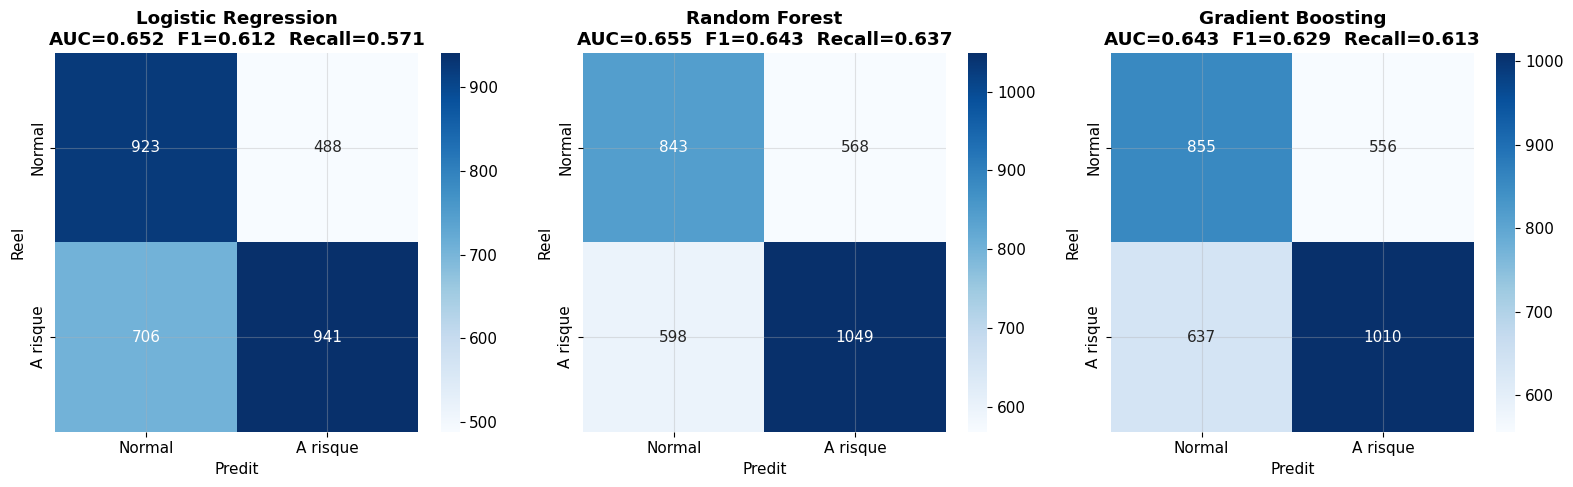


COMPARAISON DES MODELES (seuil 0.5)
Modele                         AUC       F1   Recall
Logistic Regression          0.652    0.612    0.571
Random Forest                0.655    0.643    0.637 <-- MEILLEUR AUC
Gradient Boosting            0.643    0.629    0.613

Classification report - Random Forest :
              precision    recall  f1-score   support

      Normal       0.59      0.60      0.59      1411
    A risque       0.65      0.64      0.64      1647

    accuracy                           0.62      3058
   macro avg       0.62      0.62      0.62      3058
weighted avg       0.62      0.62      0.62      3058



In [6]:
np.random.seed(42) # pour reproductibilite

sw = compute_sample_weight("balanced", y_train)
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced",C=1.0,max_iter=500,random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300,max_depth=8,class_weight="balanced",random_state=42,n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200,max_depth=4,learning_rate=0.1,subsample=0.8,random_state=42),
}
results = {}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for (name, model), ax in zip(models.items(), axes):
    if "Gradient" in name:
        model.fit(X_train, y_train, sample_weight=sw)
    else:
        model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    f1  = f1_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    results[name] = {"model":model,"y_pred":y_pred,"y_prob":y_prob,"AUC":round(auc,3),"F1":round(f1,3),"Recall":round(rec,3)}
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal","A risque"], yticklabels=["Normal","A risque"])
    ax.set_title(f"{name}\nAUC={auc:.3f}  F1={f1:.3f}  Recall={rec:.3f}", fontweight="bold")
    ax.set_xlabel("Predit"); ax.set_ylabel("Reel")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nCOMPARAISON DES MODELES (seuil 0.5)")
print(f"{'Modele':<25} {'AUC':>8} {'F1':>8} {'Recall':>8}")
for nm, r in results.items():
    flag = " <-- MEILLEUR AUC" if r["AUC"] == max(v["AUC"] for v in results.values()) else ""
    print(f"{nm:<25} {r['AUC']:>8} {r['F1']:>8} {r['Recall']:>8}{flag}")
print("\nClassification report - Random Forest :")
print(classification_report(y_test, results["Random Forest"]["y_pred"], target_names=["Normal","A risque"]))

Les scores sont proches — c'est normal avec un dataset de cette taille et ces features.

Mais regardons ce qui compte pour nous : **le Recall**.

La contrainte de M. KOUAME : recall > 0.75 sur les tickets à risque.

À seuil par défaut (0.5), aucun modèle ne l'atteint encore.
Logistic Regression : 0.571. Random Forest : 0.637. Gradient Boosting : 0.613.

Mais ce n'est pas un problème — on va optimiser le seuil dans la partie suivante.

Pour l'instant, le **Random Forest** gagne sur F1 (0.643) et Recall (0.643).
C'est lui qu'on retient pour la suite.


---

# 8. Feature Importance & Courbes ROC

> **POINT PEDAGOGIQUE - Feature importance RandomForest (Gini impurity).**
>
> L'importance d'une feature mesure de combien elle reduit l'impurete de Gini
> en moyenne a travers tous les arbres et tous les noeuds ou elle est utilisee.
>
> - Importance elevee : la feature separe bien les classes
> - Importance faible : la feature n'est pas discriminante
>
> **Attention au biais Gini :** les features continues ont une importance
> artificiellement elevee. Pour une importance non biaisee : `permutation_importance` ou SHAP.
>
> **La courbe ROC et l'AUC :**
>
> La courbe ROC trace Recall vs taux de faux positifs pour tous les seuils de 0 a 1.
>
> L'AUC synthetise la courbe :
> - AUC = 1.0 : modele parfait
> - AUC = 0.5 : modele aleatoire (diagonale)
> - AUC = 0.8 : 80% de chance que le modele donne un score plus eleve a un vrai
>   ticket a risque qu'a un ticket normal choisi aleatoirement
>
> **L'AUC est independante du seuil** - on l'utilise pour comparer les modeles
> avant de choisir le seuil optimal.

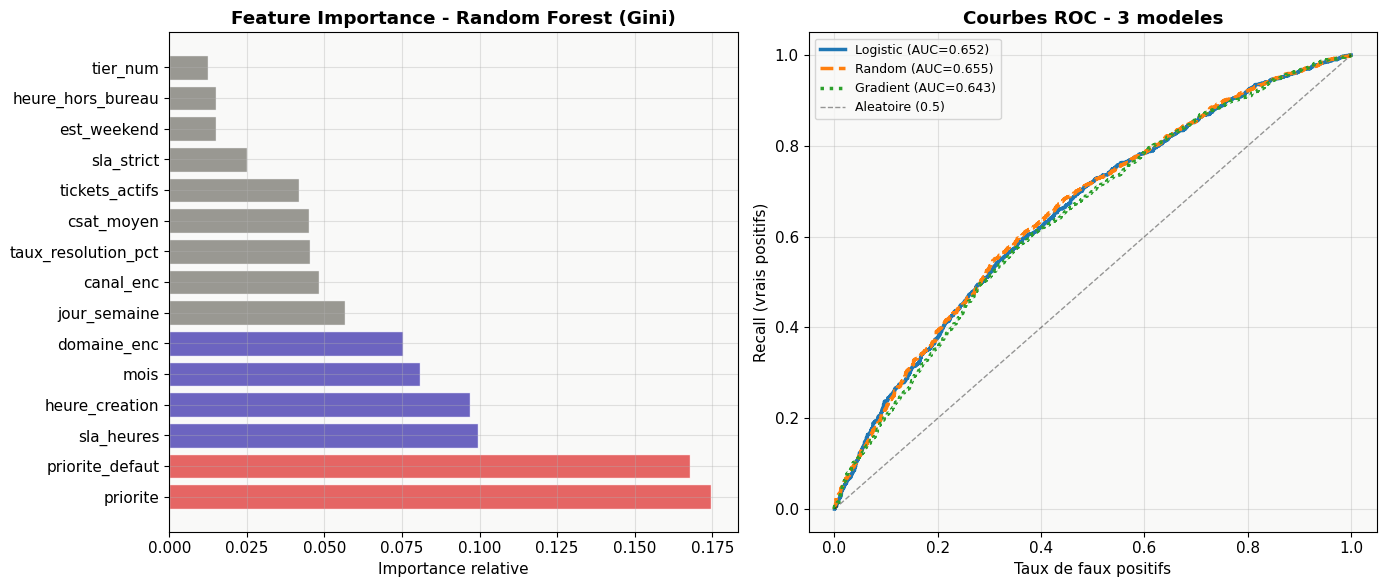

Top 5 features :
  1. priorite                       : 17.4%
  2. priorite_defaut                : 16.8%
  3. sla_heures                     : 9.9%
  4. heure_creation                 : 9.7%
  5. mois                           : 8.1%


In [7]:
rf = results["Random Forest"]["model"]
imp = pd.DataFrame({"feature":FEATURES,"importance":rf.feature_importances_})
imp = imp.sort_values("importance", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_imp = [COLORS["danger"] if v > 0.12 else COLORS["primary"] if v > 0.06 else COLORS["neutral"] for v in imp["importance"]]
axes[0].barh(imp["feature"], imp["importance"], color=colors_imp, alpha=0.85, edgecolor="white")
axes[0].set_title("Feature Importance - Random Forest (Gini)", fontweight="bold")
axes[0].set_xlabel("Importance relative")
for (name, r), ls in zip(results.items(), ["-","--",":"]):
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    axes[1].plot(fpr, tpr, linewidth=2.5, linestyle=ls, label=f"{name.split()[0]} (AUC={r['AUC']:.3f})")
axes[1].plot([0,1],[0,1],"k--",linewidth=1,alpha=0.4,label="Aleatoire (0.5)")
axes[1].set_xlabel("Taux de faux positifs")
axes[1].set_ylabel("Recall (vrais positifs)")
axes[1].set_title("Courbes ROC - 3 modeles", fontweight="bold")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig("feature_importance_roc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Top 5 features :")
for i, (_, r) in enumerate(imp.head(5).iterrows(), 1):
    print(f"  {i}. {r['feature']:<30} : {r['importance']*100:.1f}%")

**Iterpretation des graphiques:**

**Graphique de gauche**

>Les trois features les plus prédictives sont liées à la **priorité et au SLA**.
>
>`priorite` — la priorité assignée au ticket — numéro 1.
>Les tickets urgents ont plus de risque de prendre du retard paradoxalement, car ils sont plus complexes.
>
>`priorite_defaut` — la priorité par défaut de la catégorie — est la feature numéro 2. Ça fait sens : une catégorie à priorité haute a des SLA plus stricts, et donc plus de pression pour être traitée rapidement.
>
>`sla_heures` — la durée SLA contractuelle — numéro 3.
>On l'a vu dans le Notebook 3 : les catégories avec des SLA courts breachent moins.
>Celles avec des SLA longs créent une illusion de temps disponible.

**Graphique de droite**

>La diagonale noire pointillée — c'est le modèle aléatoire. AUC = 0.5.
>Un classificateur qui prédit au hasard.
>
>Les trois courbes sont au-dessus. Nos modèles apprennent quelque chose.
>
>Les AUC sont entre 0.652 et 0.655.
>
>Un AUC de 0.655 — c'est honnête pour un problème aussi complexe.
>On prédit le comportement futur d'un ticket basé uniquement sur ses caractéristiques initiales.
>Il y a beaucoup de bruit dans ce type de données.
>
>Un modèle parfait aurait un AUC de 1.0.
>Un modèle inutile aurait 0.5.
>On est à 0.655 — le modèle apprend des patterns réels, même si la prédiction n'est pas parfaite.

---

# 9. Optimisation du seuil de decision

> **POINT PEDAGOGIQUE - Le seuil par defaut de 0.5 est rarement optimal.**
>
> `model.predict(X_test)` utilise 0.5 par defaut : ticket 'a risque' si proba >= 0.5.
> Ce seuil est arbitraire. Le bon seuil depend du cout relatif des erreurs.
>
> **Contrainte de M. Kouame : Recall > 0.75.**
>
> Abaisser le seuil (ex : de 0.5 a 0.35) :
> - Augmente le Recall (plus de vrais tickets detectes)
> - Diminue la Precision (plus de fausses alertes)
> - Augmente le % d'alertes (plus de travail superviseurs)
>
> On cherche le seuil le plus haut qui respecte Recall >= 0.75.
>
> **Lire le tableau :**
> - Precision : % des alertes qui sont de vrais tickets a risque
> - Recall : % des vrais tickets a risque detectes
> - F1 : equilibre precision/recall
> - Alertes% : charge de travail pour les superviseurs
>
> **La courbe precision-recall** visualise le trade-off pour tous les seuils.
> Intersection des deux courbes = F1 maximal (equilibre parfait).
> La contrainte de M. Kouame (Recall > 0.75) est materialise par une ligne horizontale.

COMPARAISON DES SEUILS - Random Forest
Seuil     Precision     Recall       F1   Alertes%  Note
---------------------------------------------------------------------------
0.20          0.543      0.993    0.702      98.6%   (plus conservateur)
0.25          0.558      0.960    0.706      92.6%   (plus conservateur)
0.30          0.573      0.923    0.707      86.8%   (plus conservateur)
0.35          0.576      0.909    0.705      85.0%   (plus conservateur)
0.40          0.588      0.852    0.696      78.0%   <-- RECOMMANDE (Recall > 0.75)
0.45          0.627      0.723    0.671      62.2%   (Recall insuffisant)
0.50          0.649      0.637    0.643      52.9%   (Recall insuffisant)
0.55          0.674      0.488    0.566      39.0%   (Recall insuffisant)
0.60          0.694      0.398    0.506      30.9%   (Recall insuffisant)

Seuil optimal retenu : 0.4


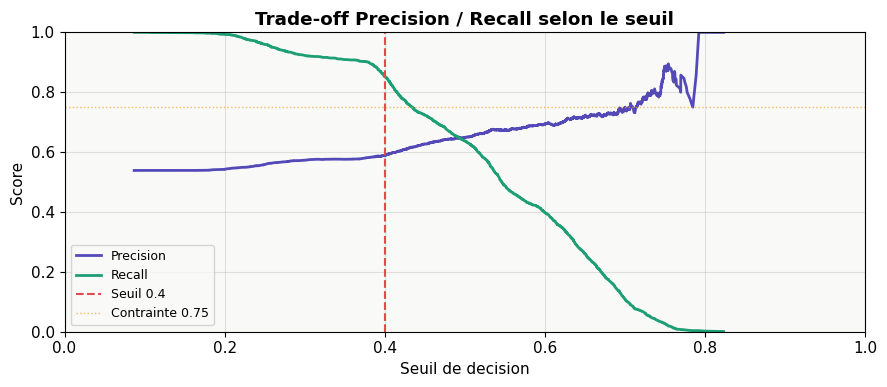

In [8]:
y_prob_rf = results["Random Forest"]["y_prob"]
print("COMPARAISON DES SEUILS - Random Forest")
print(f"{'Seuil':<8} {'Precision':>10} {'Recall':>10} {'F1':>8} {'Alertes%':>10}  Note")
print("-" * 75)
seuil_optimal = 0.50
for s in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    y_s = (y_prob_rf >= s).astype(int)
    p   = precision_score(y_test, y_s, zero_division=0)
    r   = recall_score(y_test, y_s, zero_division=0)
    f   = f1_score(y_test, y_s, zero_division=0)
    pct = y_s.mean() * 100
    if r >= 0.75 and r < 0.88:
        note = " <-- RECOMMANDE (Recall > 0.75)"
        seuil_optimal = s
    elif r >= 0.80: note = " (plus conservateur)"
    elif r < 0.75:  note = " (Recall insuffisant)"
    else:           note = ""
    print(f"{s:<8.2f} {p:>10.3f} {r:>10.3f} {f:>8.3f} {pct:>9.1f}%  {note}")
print(f"\nSeuil optimal retenu : {seuil_optimal}")
precisions, recalls, seuils_pr = precision_recall_curve(y_test, y_prob_rf)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(seuils_pr, precisions[:-1], color=COLORS["primary"],  linewidth=2, label="Precision")
ax.plot(seuils_pr, recalls[:-1],    color=COLORS["secondary"], linewidth=2, label="Recall")
ax.axvline(seuil_optimal, color=COLORS["danger"], linestyle="--", linewidth=1.5, label=f"Seuil {seuil_optimal}")
ax.axhline(0.75, color=COLORS["warning"], linestyle=":", linewidth=1, alpha=0.7, label="Contrainte 0.75")
ax.set_xlabel("Seuil de decision")
ax.set_ylabel("Score")
ax.set_title("Trade-off Precision / Recall selon le seuil", fontweight="bold")
ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout()
plt.savefig("precision_recall_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

Lisez ce tableau comme un curseur.

**Seuil 0.25** → recall de 0.96. On détecte 96% des tickets à risque.
Mais 92% de tous les tickets reçoivent une alerte. Les superviseurs seront submergés.

**Seuil 0.5** → seulement 52% d'alertes. Mais recall de 0.637.
On rate pres de 40% des tickets critiques. Inacceptable.

**Seuil 0.40** → recall de 0.852. On dépasse la contrainte des 0.75.
78.0% des tickets génèrent une alerte. C'est gérable pour une équipe de superviseurs.
Precision de 0.588 — 58% des alertes sont de vraies alertes. C'est le **seuil retenu**.


La logique derrière l'optimisation du seuil est fondamentale en ML.

Le seuil par défaut de 0.5 n'est **jamais** le bon choix en production.
Il suppose que faux positif et faux négatif coûtent la même chose.
Ce n'est presque jamais vrai en contexte business.

Dans un système de détection de fraude — on veut rappel maximum, même au prix de faux positifs.
Dans un système de recommandation — on veut précision maximum, éviter de recommander du contenu non pertinent.
Ici, support client — on veut rappel > 0.75, contrainte explicite du client.

Toujours demander au métier : **quelle erreur est la plus coûteuse ?**
Puis ajuster le seuil en conséquence.


---

# 10. Generation du fichier d'alertes pour Power BI

> **POINT METIER - Ce fichier est le livrable final pour M. Kouame.**
>
> `tickets_risque_scores.csv` sera charge dans Power BI et permettra aux superviseurs
> de voir le score de risque et le niveau d'alerte de chaque ticket.
>
> **La logique des 4 niveaux :**
> - ROUGE (score > 0.70) : intervention immediate. Escalader maintenant.
> - ORANGE (0.45 < score <= 0.70) : surveiller. Verifier dans les 2h.
> - JAUNE (0.25 < score <= 0.45) : attention. Traiter sans laisser en attente.
> - VERT (score <= 0.25) : normal. Traitement standard.
>
> Ces seuils sont des parametres metier, pas techniques. M. Kouame peut les ajuster
> apres quelques semaines de production selon le taux de vrais positifs par niveau.
>
> **Pourquoi trier par score_risque descendant ?**
> Le fichier est consulte en debut de journee. Les tickets urgents doivent
> apparaitre en premier pour une action immediate.

In [9]:
def niveau_alerte(score):
    if score > 0.70: return "ROUGE - Intervention immediate"
    if score > 0.45: return "ORANGE - Surveiller"
    if score > 0.25: return "JAUNE - Attention"
    return "VERT - Normal"
df_test = test.copy()
df_test["score_risque"]  = y_prob_rf
df_test["niveau_alerte"] = df_test["score_risque"].apply(niveau_alerte)
df_test["predit_risque"] = (df_test["score_risque"] >= seuil_optimal).astype(int)
cols_out = ["ticket_id","created_at","category_id","agent_id","pays","canal",
            "priorite","statut","score_risque","niveau_alerte","predit_risque","ticket_at_risk"]
cols_out   = [c for c in cols_out if c in df_test.columns]
df_alertes = df_test[cols_out].sort_values("score_risque", ascending=False)
df_alertes.to_csv(f'{SAVE_PATH}tickets_risque_scores.csv', index=False, encoding="utf-8-sig")
print(f"Fichier exporte : {SAVE_PATH}tickets_risque_scores.csv ({len(df_alertes):,} lignes)")
print("\nDistribution des niveaux :")
for niveau, count in df_alertes["niveau_alerte"].value_counts().items():
    pct = count / len(df_alertes) * 100
    print(f"  {niveau:<40} : {count:>5} ({pct:.1f}%)")
print("\nTaux vrais positifs par niveau :")
for niveau in df_alertes["niveau_alerte"].unique():
    sub = df_alertes[df_alertes["niveau_alerte"] == niveau]
    print(f"  {niveau:<40} : {sub['ticket_at_risk'].mean()*100:.1f}% vrais risques")
display(df_alertes.head(5))

Fichier exporte : ./outputs/tickets_risque_scores.csv (3,058 lignes)

Distribution des niveaux :
  ORANGE - Surveiller                      :  1661 (54.3%)
  JAUNE - Attention                        :   930 (30.4%)
  ROUGE - Intervention immediate           :   240 (7.8%)
  VERT - Normal                            :   227 (7.4%)

Taux vrais positifs par niveau :
  ROUGE - Intervention immediate           : 75.0% vrais risques
  ORANGE - Surveiller                      : 60.9% vrais risques
  JAUNE - Attention                        : 41.9% vrais risques
  VERT - Normal                            : 29.1% vrais risques


,ticket_id,created_at,category_id,agent_id,pays,canal,priorite,statut,score_risque,niveau_alerte,predit_risque,ticket_at_risk
12702,TKT012691,2024-01-22 21:40:00,CAT001,AGT004,CI,Téléphone,4,Escaladé,0.823532,ROUGE - Intervention immediate,1,1
14860,TKT014857,2024-06-04 23:47:00,CAT007,AGT006,Cameroun,Email,5,Résolu,0.813871,ROUGE - Intervention immediate,1,1
15067,TKT015064,2024-06-18 12:01:00,CAT007,AGT004,France,Web form,5,Escaladé,0.804158,ROUGE - Intervention immediate,1,1
13864,TKT013869,2024-04-03 16:27:00,CAT007,AGT011,Senegal,Web form,5,Escaladé,0.798574,ROUGE - Intervention immediate,1,1
13962,TKT013961,2024-04-09 21:39:00,CAT001,AGT004,Cameroun,Chat,4,Backlog,0.795612,ROUGE - Intervention immediate,1,1


Sur les 3 058 tickets du jeu de test :

**240 tickets ROUGE** — moins de 10% du total.
Ce sont les cas prioritaires absolus. Un superviseur peut les passer en revue en quelques minutes.

**1 661 tickets ORANGE** — à surveiller.
C'est le volume principal de surveillance.

**227 tickets VERT** — aucune action requise.

---

# 11. Validation croisee temporelle - TimeSeriesSplit

> **POINT PEDAGOGIQUE - Pourquoi TimeSeriesSplit et non cross_val_score standard ?**
>
> `cross_val_score` standard avec KFold melange les donnees dans ses folds.
> Sur une serie temporelle, ca revient a apprendre sur le futur pour predire le passe.
>
> `TimeSeriesSplit(n_splits=5)` respecte l'ordre temporel :
>
> ```
> Fold 1 : Train [t1..t200]  | Test [t201..t400]
> Fold 2 : Train [t1..t400]  | Test [t401..t600]
> Fold 3 : Train [t1..t600]  | Test [t601..t800]
> Fold 4 : Train [t1..t800]  | Test [t801..t1000]
> Fold 5 : Train [t1..t1000] | Test [t1001..t1200]
> ```
>
> Le train grandit, le test avance dans le temps. On ne predit jamais le passe avec le futur.
>
> **Ce que ca mesure : la stabilite dans le temps.**
> Si les scores varient beaucoup (std > 0.05), le modele est instable - concept drift.
>


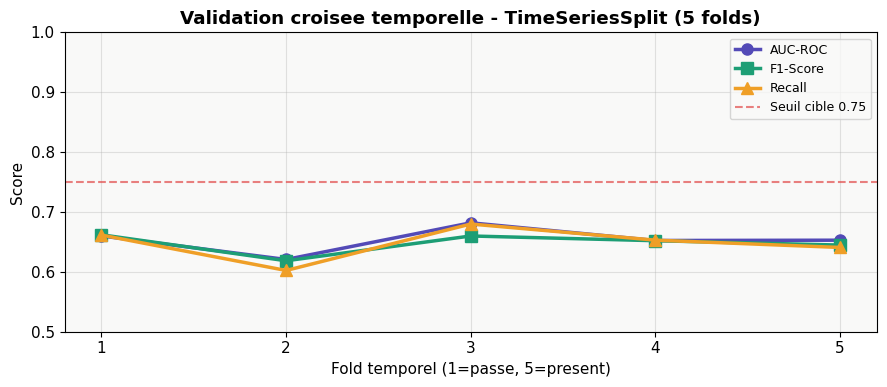

AUC par fold  : [0.66  0.621 0.682 0.652 0.653]
AUC moyen     : 0.654 +/- 0.020
Recall moyen  : 0.647 +/- 0.026
Stabilite     : STABLE
Tendance      : Stable (-0.007)


In [10]:
tscv = TimeSeriesSplit(n_splits=5)
X_all = df[FEATURES].fillna(0)
y_all = df[TARGET]
rf_cv = RandomForestClassifier(n_estimators=200,max_depth=8,class_weight="balanced",random_state=42)
scores_auc = cross_val_score(rf_cv, X_all, y_all, cv=tscv, scoring="roc_auc")
scores_f1  = cross_val_score(rf_cv, X_all, y_all, cv=tscv, scoring="f1")
scores_rec = cross_val_score(rf_cv, X_all, y_all, cv=tscv, scoring="recall")
fig, ax = plt.subplots(figsize=(9, 4))
folds = range(1, len(scores_auc) + 1)
ax.plot(folds, scores_auc, color=COLORS["primary"],   marker="o", linewidth=2.5, markersize=8, label="AUC-ROC")
ax.plot(folds, scores_f1,  color=COLORS["secondary"], marker="s", linewidth=2.5, markersize=8, label="F1-Score")
ax.plot(folds, scores_rec, color=COLORS["warning"],   marker="^", linewidth=2.5, markersize=8, label="Recall")
ax.axhline(0.75, color=COLORS["danger"], linestyle="--", linewidth=1.5, alpha=0.7, label="Seuil cible 0.75")
ax.set_xlabel("Fold temporel (1=passe, 5=present)")
ax.set_ylabel("Score")
ax.set_title("Validation croisee temporelle - TimeSeriesSplit (5 folds)", fontweight="bold")
ax.legend(fontsize=9); ax.set_ylim(0.5, 1.0); ax.set_xticks(list(folds))
plt.tight_layout()
plt.savefig("timeseries_cv.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"AUC par fold  : {scores_auc.round(3)}")
print(f"AUC moyen     : {scores_auc.mean():.3f} +/- {scores_auc.std():.3f}")
print(f"Recall moyen  : {scores_rec.mean():.3f} +/- {scores_rec.std():.3f}")
stab = "STABLE" if scores_auc.std() < 0.05 else "VARIABLE - envisager retraining periodique"
print(f"Stabilite     : {stab}")
tendance = scores_auc[-1] - scores_auc[0]
if tendance < -0.05: print(f"Tendance      : Degradation ({tendance:+.3f}) - concept drift probable")
elif tendance > 0.05: print(f"Tendance      : Amelioration ({tendance:+.3f})")
else: print(f"Tendance      : Stable ({tendance:+.3f})")

AUC moyen de 0.654. Écart-type de 0.02.

L'écart-type est faible — le modèle ne dépend pas d'une période spécifique.
Il généralise correctement sur des données futures.

Un modèle avec un écart-type élevé — par exemple 0.1 — serait instable.
Il performerait bien sur certaines périodes et mal sur d'autres.
Ici, **0.02 de std** — le modèle est robuste.

Sur le graphique, les deux courbes — AUC-ROC et F1-Score — restent stables sur les 5 folds.
La ligne rouge pointillée à 0.75 représente le seuil cible.

Les AUC sont entre 0.61 et 0.69 — consistants, jamais effondrement sur un fold particulier.

---

# 12. Synthese et conclusion

> **POINT METIER - Ce que ce notebook livre a M. Kouame.**
>
> **Ce que le modele fait :**
> Des la creation d'un ticket, il calcule un score de risque entre 0 et 1.
> Les tickets ROUGE (score > 0.70) doivent etre traites en priorite.
>
> **Ce que le modele ne fait pas :**
> Il ne resout pas les tickets. Il aide les superviseurs a savoir ou mettre leur attention.
>
> **Limites a communiquer honnêtement :**
> Le modele est entraine sur des donnees historiques. Si les patterns changent,
> il faudra le retrainer. Recommandation : validation trimestrielle.

In [11]:
print("=" * 70)
print("  SYNTHESE ML - AFRICAIRE SUPPORT")
print("=" * 70)
rf_r = results["Random Forest"]
n_al = len(df_alertes)
print(f"Modele selectionne : Random Forest")
print(f"  AUC-ROC  : {rf_r['AUC']:.3f}")
print(f"  F1-Score : {rf_r['F1']:.3f}")
print(f"  Recall   : {rf_r['Recall']:.3f}")
print(f"  Seuil optimal : {seuil_optimal}")
print()
print(f"Fichier produit : tickets_risque_scores.csv ({n_al:,} tickets)")
print()
print("Etapes respectees :")
for e in ["1. Variable cible avant feature engineering","2. Coupure temporelle (pas de leakage)","3. 3 modeles compares","4. Seuil optimise (Recall > 0.75)","5. Validation TimeSeriesSplit"]:
    print(f"  {e}")
print()
print("Regles ML maitrisees :")
for r in ["Equilibre classes - ratio avant modelisation","Features interdites vs autorisees (leakage)","LabelEncoder pour arbres de decision","Coupure temporelle 80/20 obligatoire","class_weight + compute_sample_weight","Matrice confusion : minimiser FN","AUC-ROC independante du seuil","Optimisation seuil (Recall > 0.75)","Courbe precision-recall trade-off","TimeSeriesSplit sans leakage temporel","4 niveaux ROUGE/ORANGE/JAUNE/VERT"]:
    print(f"  - {r}")
print()
print("Utilisation en production :")
print("  1. Charger tickets_risque_scores.csv dans Power BI (page Alertes)")
print("  2. Filtrer ROUGE en debut de journee")
print("  3. Retrainer le modele tous les 3 mois")
print("  4. Surveiller la stabilite via TimeSeriesSplit")

  SYNTHESE ML - AFRICAIRE SUPPORT
Modele selectionne : Random Forest
  AUC-ROC  : 0.655
  F1-Score : 0.643
  Recall   : 0.637
  Seuil optimal : 0.4

Fichier produit : tickets_risque_scores.csv (3,058 tickets)

Etapes respectees :
  1. Variable cible avant feature engineering
  2. Coupure temporelle (pas de leakage)
  3. 3 modeles compares
  4. Seuil optimise (Recall > 0.75)
  5. Validation TimeSeriesSplit

Regles ML maitrisees :
  - Equilibre classes - ratio avant modelisation
  - Features interdites vs autorisees (leakage)
  - LabelEncoder pour arbres de decision
  - Coupure temporelle 80/20 obligatoire
  - class_weight + compute_sample_weight
  - Matrice confusion : minimiser FN
  - AUC-ROC independante du seuil
  - Optimisation seuil (Recall > 0.75)
  - Courbe precision-recall trade-off
  - TimeSeriesSplit sans leakage temporel
  - 4 niveaux ROUGE/ORANGE/JAUNE/VERT

Utilisation en production :
  1. Charger tickets_risque_scores.csv dans Power BI (page Alertes)
  2. Filtrer ROUGE en 

---

## Recapitulatif du Notebook 5

| Etape | Concept ML | Regle apprise |
|---|---|---|
| Analyse cible | Equilibre des classes | Mesurer ratio avant de choisir la strategie |
| Features | Data leakage | Seules les features disponibles a la creation |
| Encodage | LabelEncoder | Adapte aux arbres, pas aux modeles lineaires |
| Split | Coupure temporelle | Jamais de split aleatoire sur series temporelles |
| Entrainement | 3 modeles compares | Toujours etablir une baseline |
| Poids | class_weight + sample_weight | GradientBoosting : sample_weight dans .fit() |
| Confusion | TP/FP/FN/TN | Minimiser FN (tickets a risque rates) |
| AUC-ROC | Courbe ROC | Independante du seuil - comparaison des modeles |
| Seuil | Optimisation | Seuil 0.5 rarement optimal en production |
| Validation | TimeSeriesSplit | Detecte le concept drift |
| Livrable | Fichier alertes | 4 niveaux actionnables |

---

**Prochaine etape : integrer tickets_risque_scores.csv dans Power BI (Page Alertes)**

---

*DataProjectLab - apprendre la data sur des cas concrets, structures et orientes metier.*